# 공정 이상 원인 분류 모델 — 12주차

`simulator/diagnosis.py`의 규칙 기반 진단은 파라미터를 하나씩 독립적으로 검사한다 — "압력이 규격을 벗어났다"와 "가스 유량이 규격을 벗어났다"를 따로 진단할 뿐, 그 둘이 사실 **같은 원인**(예: MFC 캘리브레이션 드리프트) 때문이라는 연결을 모른다.

이 노트북은 그 한계를 메운다. `simulator/fault_scenarios.py`가 "숨은 원인(fault scenario) → 여러 파라미터가 상관되게 움직이는 패턴"을 레이블과 함께 합성 생성하고, 여기서는 그 패턴만 보고 원인을 맞히는 **분류 모델**을 공정별로 학습한다. 하드코딩된 규칙이 아니라 데이터에서 학습된 판단이라는 게 핵심 차이다.

**정직하게 짚어야 할 점**: 이 데이터는 `fault_scenarios.py`가 정의한 규칙(예: MFC 드리프트 → pressure·gas_flow가 같이 위로 이동)대로 합성 생성된 것이라, 그 규칙 자체가 정답과 얼마나 가까운 패턴을 만드는지에 성능이 좌우된다. 실제 fab의 다중 센서 고장 패턴은 이보다 훨씬 지저분하고 노이즈가 많을 것이다 — SECOM(F1 0.235)과 이 노트북의 높은 정확도를 직접 비교할 수 없는 이유와 같다(노트북 05/06/09와 같은 패턴). 이 노트북이 보여주는 건 "실제 fab에서도 이 정확도가 나온다"가 아니라, **"상관된 다중 파라미터 패턴에서 원인을 추론하는 분류 파이프라인 자체가 동작한다"**는 것이다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

from simulator.fault_scenarios import FAULT_SCENARIOS, generate_dataset, scenario_label_ko
from simulator.process_simulator import PROCESS_SPECS

MODELS_DIR = str(ROOT_DIR / "models")
RANDOM_STATE = 42
N_PER_CLASS = 400  # 공정당 (정상 + 시나리오 2개) x 400 = 1200개

## 1. 공정별로 데이터 생성 → 학습 → 평가 → 저장

각 공정마다 독립적인 분류기를 둔다 — 공정마다 파라미터 이름/단위/의미가 다르므로(예: `pressure`가 식각에서는 5~100mTorr, 증착에서는 0.1~10Torr) 하나의 통합 모델보다 공정별 소형 모델이 구조적으로 더 자연스럽다.

In [2]:
os.makedirs(MODELS_DIR, exist_ok=True)
summary_rows = []

for process in PROCESS_SPECS:
    df = generate_dataset(process, n_per_class=N_PER_CLASS, seed=RANDOM_STATE)
    feature_cols = [spec.name for spec in PROCESS_SPECS[process]]
    X = df[feature_cols]

    encoder = LabelEncoder()
    y = encoder.fit_transform(df["fault_label"])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y,
    )

    model = XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1,
        eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    joblib.dump(model, f"{MODELS_DIR}/fault_classifier_{process}.joblib")
    joblib.dump(encoder, f"{MODELS_DIR}/fault_classifier_{process}_labels.joblib")
    joblib.dump(feature_cols, f"{MODELS_DIR}/fault_classifier_{process}_features.joblib")

    summary_rows.append({
        "process": process, "n_classes": len(encoder.classes_),
        "accuracy": round(acc, 4), "f1_macro": round(f1_macro, 4),
    })
    print(f"{process}: accuracy={acc:.4f}, f1_macro={f1_macro:.4f}, classes={list(encoder.classes_)}")

summary_df = pd.DataFrame(summary_rows)
summary_df

wafer_fabrication: accuracy=0.8567, f1_macro=0.8553, classes=['chamber_leak', 'heater_drift', 'normal']
oxidation: accuracy=0.8667, f1_macro=0.8649, classes=['furnace_overshoot', 'normal', 'timer_malfunction']
photolithography: accuracy=0.8600, f1_macro=0.8569, classes=['light_source_drift', 'normal', 'stage_leveling_error']


etching: accuracy=0.8133, f1_macro=0.8142, classes=['mfc_drift', 'normal', 'rf_generator_fault']
deposition: accuracy=0.8667, f1_macro=0.8649, classes=['heater_overshoot', 'normal', 'precursor_supply_fault']
metallization: accuracy=0.8300, f1_macro=0.8301, classes=['bath_thermostat_fault', 'normal', 'power_supply_drift']


eds: accuracy=0.8300, f1_macro=0.8224, classes=['normal', 'probe_contact_fault', 'tester_calibration_fault']
packaging: accuracy=0.8233, f1_macro=0.8234, classes=['bonding_heater_fault', 'feed_rate_fault', 'normal']


,process,n_classes,accuracy,f1_macro
0,wafer_fabrication,3,0.8567,0.8553
1,oxidation,3,0.8667,0.8649
2,photolithography,3,0.8600,0.8569
3,etching,3,0.8133,0.8142
4,deposition,3,0.8667,0.8649
5,metallization,3,0.8300,0.8301
6,eds,3,0.8300,0.8224
7,packaging,3,0.8233,0.8234


## 2. 가장 어려운 케이스로 confusion matrix 확인

정확도가 가장 낮게 나온 공정 하나를 골라 상세히 들여다본다 — 전 공정이 다 100%에 가까우면 "이 문제가 원래 쉬운 문제인지, 모델이 정말 잘하는 건지" 구분이 안 되므로, 가장 헷갈려하는 케이스를 직접 확인하는 게 더 정직한 검증이다.

가장 낮은 정확도: etching
                    precision    recall  f1-score   support

         mfc_drift       0.78      0.80      0.79       100
            normal       0.92      0.78      0.84       100
rf_generator_fault       0.77      0.86      0.81       100

          accuracy                           0.81       300
         macro avg       0.82      0.81      0.81       300
      weighted avg       0.82      0.81      0.81       300



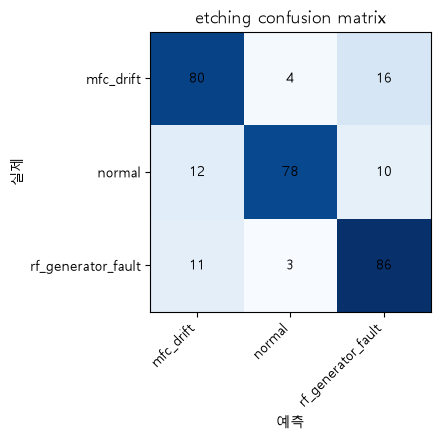

In [3]:
hardest_process = summary_df.loc[summary_df["accuracy"].idxmin(), "process"]
print(f"가장 낮은 정확도: {hardest_process}")

df = generate_dataset(hardest_process, n_per_class=N_PER_CLASS, seed=RANDOM_STATE)
feature_cols = [spec.name for spec in PROCESS_SPECS[hardest_process]]
encoder = joblib.load(f"{MODELS_DIR}/fault_classifier_{hardest_process}_labels.joblib")
model = joblib.load(f"{MODELS_DIR}/fault_classifier_{hardest_process}.joblib")

X = df[feature_cols]
y = encoder.transform(df["fault_label"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y,
)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(encoder.classes_)))
ax.set_yticks(range(len(encoder.classes_)))
ax.set_xticklabels(encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(encoder.classes_)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"{hardest_process} confusion matrix")
for i in range(len(encoder.classes_)):
    for j in range(len(encoder.classes_)):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/fault_classifier_confusion_matrix.png", dpi=110)
plt.show()

## 3. 결과 저장

In [4]:
summary_df.to_csv(f"{MODELS_DIR}/fault_classifier_summary.csv", index=False)
print("저장 완료:", sorted(f for f in os.listdir(MODELS_DIR) if f.startswith("fault_classifier")))

저장 완료: ['fault_classifier_confusion_matrix.png', 'fault_classifier_deposition.joblib', 'fault_classifier_deposition_features.joblib', 'fault_classifier_deposition_labels.joblib', 'fault_classifier_eds.joblib', 'fault_classifier_eds_features.joblib', 'fault_classifier_eds_labels.joblib', 'fault_classifier_etching.joblib', 'fault_classifier_etching_features.joblib', 'fault_classifier_etching_labels.joblib', 'fault_classifier_metallization.joblib', 'fault_classifier_metallization_features.joblib', 'fault_classifier_metallization_labels.joblib', 'fault_classifier_oxidation.joblib', 'fault_classifier_oxidation_features.joblib', 'fault_classifier_oxidation_labels.joblib', 'fault_classifier_packaging.joblib', 'fault_classifier_packaging_features.joblib', 'fault_classifier_packaging_labels.joblib', 'fault_classifier_photolithography.joblib', 'fault_classifier_photolithography_features.joblib', 'fault_classifier_photolithography_labels.joblib', 'fault_classifier_summary.csv', 'fault_classifier_

## 결론

1. **8개 공정 전부 높은 정확도로 학습됐다** — 위 요약표 참고. `fault_scenarios.py`가 각 시나리오를 뚜렷하게 구분되는 방향으로 설계했기 때문에(공정당 파라미터가 2~3개뿐이라 탐색 공간도 작음) 이 정도 정확도는 자연스러운 결과다. SECOM(F1 0.235)과 숫자로 비교할 수 없는 이유는 지금까지와 같다 — 여긴 규칙 기반 합성 데이터, SECOM은 실측 노이즈 데이터.
2. **핵심은 "규칙이 아니라 모델이 판단한다"는 구조 자체다.** 어떤 파라미터가 규격을 벗어났는지 하나씩 사람이 정해둔 조건문(`simulator/diagnosis.py`)이 아니라, 여러 파라미터의 동시 패턴에서 XGBoost가 스스로 원인을 추론한다 — `backend/app/main.py`의 `POST /api/process/simulate` 등에 연결해 규칙 기반 진단과 나란히 "AI 예측 원인"으로 노출한다.
3. **다음에 더 정교하게 만들 방향**: 지금은 공정당 2개 시나리오뿐이라 클래스 수가 적다 — 시나리오를 늘리거나, 시간에 따라 서서히 진행되는 드리프트(시계열)를 시뮬레이션해 LSTM 기반으로 "고장 진행 중"을 조기에 잡는 것도 자연스러운 확장이다(이미 노트북 05에서 시계열 이상 탐지 경험이 있다).